In [1]:
!pip install spacy fasttext pandas tqdm
!python -m spacy download en_core_web_sm

  Using cached spacy_legacy-3.0.12-py2.py3-none-any.whl.metadata (2.8 kB)
  Using cached spacy_loggers-1.0.5-py3-none-any.whl.metadata (23 kB)
  Using cached wasabi-1.1.3-py3-none-any.whl.metadata (28 kB)
  Using cached catalogue-2.0.10-py3-none-any.whl.metadata (14 kB)
  Using cached weasel-0.4.3-py3-none-any.whl.metadata (4.6 kB)
  Using cached confection-0.1.5-py3-none-any.whl.metadata (19 kB)
  Using cached cloudpathlib-0.23.0-py3-none-any.whl.metadata (16 kB)
  Using cached smart_open-7.5.0-py3-none-any.whl.metadata (24 kB)
  Using cached shellingham-1.5.4-py2.py3-none-any.whl.metadata (3.5 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.0/31.0 MB 51.1 MB/s  0:00:00m0:00:0100:01
Using cached catalogue-2.0.10-py3-none-any.whl (17 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.3/780.3 kB 28.4 MB/s  0:00:00
Using cached spacy_legacy-3.0.12-py2.py3-none-any.whl (29 kB)
Using cached spacy_loggers-1.0.5-py3-none-any.w

In [2]:
!wget https://dl.fbaipublicfiles.com/fasttext/supervised-models/lid.176.bin

--2026-02-20 08:51:46--  https://dl.fbaipublicfiles.com/fasttext/supervised-models/lid.176.bin
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 13.33.67.42, 13.33.67.91, 13.33.67.77, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|13.33.67.42|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 131266198 (125M) [application/octet-stream]
Saving to: ‘lid.176.bin.1’

lid.176.bin.1       100%[===================>] 125.18M  88.1MB/s    in 1.4s    

2026-02-20 08:51:48 (88.1 MB/s) - ‘lid.176.bin.1’ saved [131266198/131266198]



In [24]:
import fasttext
import spacy
import pandas as pd
from tqdm import tqdm

# Load fastText language ID model
ft_model = fasttext.load_model("lid.176.bin")

# Load spaCy English POS model
nlp = spacy.load("en_core_web_sm")

In [25]:
df = pd.read_parquet("hf://datasets/gentaiscool/codemixqa/data/test-00000-of-00001.parquet")

In [26]:
language_map = {
    "Hindi": "hi",
    "Bengali": "bn",
    "Urdu": "ur",
    "Japanese": "ja",
    "Marathi": "mr",
    "Korean": "ko",
    "Simplified Chinese": "zh",
    "Toba Batak": "bbc",   # check ISO
    "Indonesian": "id",
    "Italian": "it",
    "Spanish": "es",
    "French": "fr",
    "Bengali transliterated": "bn",
    "Hindi transliterated": "hi",
    "Marathi transliterated": "mr",
    "Urdu transliterated": "ur",
    "English": "en"
}

In [27]:
def detect_language_constrained(token, allowed_lang):
    pred = ft_model.predict(token)[0][0].replace("__label__", "")
    
    if pred == "en":
        return "en"
    elif pred == allowed_lang:
        return allowed_lang
    else:
        return "other"

In [28]:
analysis_results = []

for idx, row in df.iterrows():
    text = row["problem"]
    dataset_lang = row["language"]
    allowed_lang = language_map.get(dataset_lang, None)

    doc = nlp(text)

    tokens_info = []
    prev_lang = None
    switch_count = 0

    for token in doc:
        if token.is_space or token.is_punct:
            continue
        
        lang = detect_language_constrained(token.text, allowed_lang)

        if prev_lang and lang != prev_lang:
            switch_count += 1
        
        prev_lang = lang

        tokens_info.append({
            "token": token.text,
            "pos": token.pos_,
            "lang": lang
        })

    analysis_results.append({
        "language": dataset_lang,
        "tokens": tokens_info,
        "switch_count": switch_count,
        "token_count": len(tokens_info)
    })

In [29]:
records = []

for item in analysis_results:
    for t in item["tokens"]:
        records.append({
            "dataset_language": item["language"],
            "token_lang": t["lang"],
            "pos": t["pos"]
        })

token_df = pd.DataFrame(records)

In [30]:
pos_dist = token_df.groupby(
    ["dataset_language", "token_lang", "pos"]
).size().reset_index(name="count")

pos_dist["percent"] = pos_dist.groupby(
    ["dataset_language", "token_lang"]
)["count"].transform(lambda x: x / x.sum())

In [31]:
english_only = pos_dist[pos_dist["token_lang"] == "en"]

In [34]:
english_only

,dataset_language,token_lang,pos,count,percent
17,Bengali,en,ADJ,1841,0.061289
18,Bengali,en,ADP,2341,0.077935
19,Bengali,en,ADV,234,0.007790
20,Bengali,en,AUX,693,0.023071
21,Bengali,en,CCONJ,321,0.010686
...,...,...,...,...,...
673,Urdu transliterate,en,PROPN,20870,0.519529
674,Urdu transliterate,en,PUNCT,2,0.000050
675,Urdu transliterate,en,SCONJ,129,0.003211
676,Urdu transliterate,en,VERB,2464,0.061338


In [38]:
english_only["token_lang"]

17     en
18     en
19     en
20     en
21     en
       ..
673    en
674    en
675    en
676    en
677    en
Name: token_lang, Length: 252, dtype: object

In [32]:
non_en = pos_dist[pos_dist["token_lang"] != "en"]

In [39]:
non_en

,dataset_language,token_lang,pos,count,percent
0,Bengali,bn,ADJ,912,0.036072
1,Bengali,bn,ADP,552,0.021833
2,Bengali,bn,ADV,131,0.005181
3,Bengali,bn,AUX,81,0.003204
4,Bengali,bn,CCONJ,60,0.002373
...,...,...,...,...,...
690,Urdu transliterate,other,PUNCT,4,0.000121
691,Urdu transliterate,other,SCONJ,27,0.000818
692,Urdu transliterate,other,SYM,4,0.000121
693,Urdu transliterate,other,VERB,679,0.020581


In [37]:
switch_stats = pd.DataFrame([
    {
        "language": item["language"],
        "token_count": item["token_count"] if item["token_count"] > 0 else 0,
        "switch_density": item["switch_count"] / item["token_count"] if item["token_count"] > 0 else 0  
    }
    for item in analysis_results
])

switch_summary = switch_stats.groupby("language").mean().reset_index()
print(switch_summary.sort_values("switch_density", ascending=False))

                 language  token_count  switch_density
14                   Urdu     18.27625        0.564422
9                 Marathi     16.25225        0.545907
3                   Hindi     17.95725        0.527004
0                 Bengali     16.14700        0.509529
11     Simplified Chinese     11.93775        0.504911
5              Indonesian     15.78975        0.498147
6                 Italian     17.14600        0.497296
2                  French     18.04675        0.492657
12                Spanish     17.57650        0.490246
4     Hindi transliterate     17.95975        0.466894
7                Japanese     10.01725        0.464325
15     Urdu transliterate     18.29050        0.452846
1   Bengali transliterate     16.22475        0.422911
10  Marathi transliterate     16.26550        0.404223
8                  Korean     13.58325        0.401370
13             Toba Batak     17.15650        0.366677


In [40]:
en_pos = english_only.pivot_table(
    index=["dataset_language", "pos"],
    values="percent",
    aggfunc="sum"
).reset_index().rename(columns={"percent": "en_percent"})

non_en_pos = non_en.pivot_table(
    index=["dataset_language", "pos"],
    values="percent",
    aggfunc="sum"
).reset_index().rename(columns={"percent": "non_en_percent"})

merged = en_pos.merge(non_en_pos, on=["dataset_language", "pos"], how="outer").fillna(0)

In [41]:
merged["en_ratio"] = merged["en_percent"] / (merged["en_percent"] + merged["non_en_percent"] + 1e-9)

In [42]:
merged.sort_values("en_ratio", ascending=False).head(20)

,dataset_language,pos,en_percent,non_en_percent,en_ratio
90,Indonesian,DET,0.071423,0.000000,1.000000
226,Toba Batak,DET,0.060615,0.000102,0.998313
22,Bengali transliterate,DET,0.046966,0.000155,0.996705
106,Italian,CCONJ,0.016083,0.000074,0.995442
208,Spanish,CCONJ,0.013280,0.000108,0.991905
225,Toba Batak,CCONJ,0.008114,0.000179,0.978382
243,Urdu,DET,0.050275,0.001332,0.974185
141,Korean,DET,0.104397,0.003415,0.968327
21,Bengali transliterate,CCONJ,0.008228,0.000272,0.968034
5,Bengali,DET,0.059258,0.002567,0.958473


In [43]:
merged.sort_values("en_ratio").head(20)

,dataset_language,pos,en_percent,non_en_percent,en_ratio
48,French,SYM,0.0,0.000181,0.0
80,Hindi transliterate,PUNCT,0.0,0.000189,0.0
82,Hindi transliterate,SYM,0.0,0.000126,0.0
63,Hindi,PUNCT,0.0,0.016639,0.0
97,Indonesian,PUNCT,0.0,0.000660,0.0
99,Indonesian,SYM,0.0,0.000257,0.0
31,Bengali transliterate,SYM,0.0,0.000155,0.0
114,Italian,PUNCT,0.0,0.000375,0.0
116,Italian,SYM,0.0,0.000421,0.0
133,Japanese,SYM,0.0,0.000393,0.0


In [44]:
merged.groupby("pos")["en_ratio"].mean().sort_values(ascending=False)

pos
DET      0.917662
CCONJ    0.895470
AUX      0.808183
PRON     0.793310
SCONJ    0.740376
ADP      0.734296
VERB     0.523049
ADJ      0.492030
ADV      0.446455
NOUN     0.334121
PROPN    0.332366
NUM      0.280051
PUNCT    0.144301
PART     0.133855
INTJ     0.058826
X        0.024441
SYM      0.015508
Name: en_ratio, dtype: float64

Text(0.5, 1.0, 'English vs Non-English POS Distribution in Code-Switched Queries')

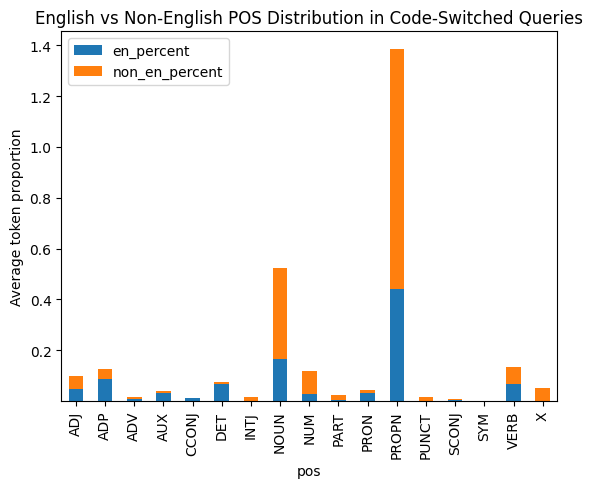

In [45]:
import matplotlib.pyplot as plt

avg = merged.groupby("pos")[["en_percent", "non_en_percent"]].mean()
avg.plot(kind="bar", stacked=True)
plt.ylabel("Average token proportion")
plt.title("English vs Non-English POS Distribution in Code-Switched Queries")

<Axes: xlabel='pos', ylabel='dataset_language'>

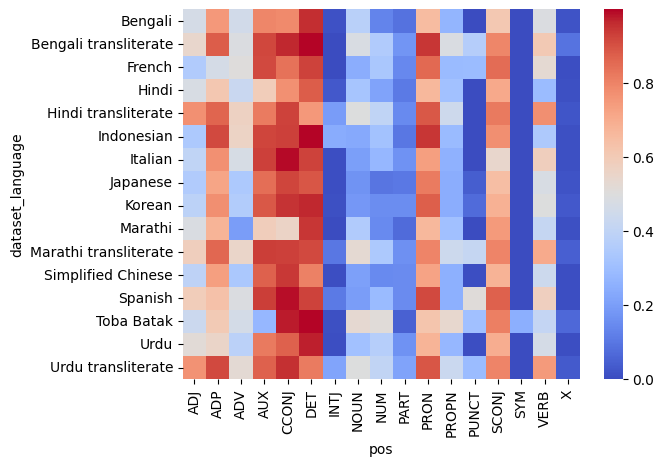

In [46]:
import seaborn as sns

pivot = merged.pivot(index="dataset_language", columns="pos", values="en_ratio")
sns.heatmap(pivot, cmap="coolwarm")

In [51]:
roman_langs = ["transliterate", "italian", "spanish", "french", "indonesian"]

merged["script"] = merged["dataset_language"].apply(
    lambda x: "roman" if any(lang in x.lower() for lang in roman_langs) else "native"
)
merged.groupby(["script", "pos"])["en_ratio"].mean()

script  pos  
native  ADJ      0.439821
        ADP      0.679864
        ADV      0.370883
        AUX      0.709284
        CCONJ    0.848367
        DET      0.927934
        INTJ     0.009253
        NOUN     0.307539
        NUM      0.220769
        PART     0.111161
        PRON     0.713500
        PROPN    0.305421
        PUNCT    0.054301
        SCONJ    0.699014
        SYM      0.031015
        VERB     0.436764
        X        0.020725
roman   ADJ      0.544239
        ADP      0.788727
        ADV      0.522027
        AUX      0.907082
        CCONJ    0.942574
        DET      0.907390
        INTJ     0.108399
        NOUN     0.360704
        NUM      0.339333
        PART     0.156549
        PRON     0.873119
        PROPN    0.359311
        PUNCT    0.234301
        SCONJ    0.781737
        SYM      0.000000
        VERB     0.609333
        X        0.028157
Name: en_ratio, dtype: float64

In [48]:
content_pos = ["NOUN", "PROPN", "VERB", "ADJ"]
content = merged[merged.pos.isin(content_pos)]
content.groupby("dataset_language")["en_ratio"].mean()

dataset_language
Bengali                  0.401496
Bengali transliterate    0.530248
French                   0.352837
Hindi                    0.352495
Hindi transliterate      0.621510
Indonesian               0.301395
Italian                  0.360231
Japanese                 0.311550
Korean                   0.328036
Marathi                  0.390716
Marathi transliterate    0.563807
Simplified Chinese       0.321478
Spanish                  0.405321
Toba Batak               0.480640
Urdu                     0.392680
Urdu transliterate       0.611824
Name: en_ratio, dtype: float64